In [1]:
import sys, os, glob, json

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SRC = os.path.join(REPO_ROOT, "omicsdrp", "src")
DATASET_PATH = os.path.join(REPO_ROOT, "data")
INFERENCE_ROOT = os.path.join(REPO_ROOT, "omicsdrp", "scripts", "InferenceModels")

sys.path.insert(0, SRC)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from omicsdrp.data import load_raw, select_omics, stack_gene_data
from omicsdrp.inference_models import InferenceEnsemble, _apply_saved_scaler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print("dataset path:", DATASET_PATH)
print("inference models root:", INFERENCE_ROOT)


device: cuda
dataset path: /project/OmicsDRP_Review/data
inference models root: /project/OmicsDRP_Review/omicsdrp/scripts/InferenceModels


In [2]:
available = sorted(
    d for d in os.listdir(INFERENCE_ROOT)
    if os.path.isfile(os.path.join(INFERENCE_ROOT, d, "config.json"))
)
print(f"{len(available)} conditions found:")
for c in available:
    print(" -", c)

# 기본값: 전체 omics + attention + morgan 조건을 우선 사용, 없으면 첫 번째 조건 사용
preferred = [c for c in available if c.startswith("SNP+MET+CNV+RNA__attention__morgan")]
CONDITION_TAG = preferred[0] if preferred else available[0]
COND_DIR = os.path.join(INFERENCE_ROOT, CONDITION_TAG)
print("\nusing condition:", CONDITION_TAG)

with open(os.path.join(COND_DIR, "config.json")) as fh:
    print(json.dumps(json.load(fh), indent=2))


12 conditions found:
 - CNV+RNA__attention__morgan__mixed__47a229
 - MET+CNV+RNA__attention__morgan__mixed__6589e6
 - MET+RNA__attention__morgan__mixed__b45cf1
 - SNP+CNV+RNA__attention__morgan__mixed__ad3e70
 - SNP+MET+CNV+RNA__attention__chemberta__mixed__516575
 - SNP+MET+CNV+RNA__attention__graphormer__mixed__672988
 - SNP+MET+CNV+RNA__attention__molformer__mixed__6548ee
 - SNP+MET+CNV+RNA__attention__morgan__mixed__c94ea3
 - SNP+MET+CNV+RNA__attention__unimol__mixed__c79b1c
 - SNP+MET+CNV+RNA__mlp__morgan__mixed__444b73
 - SNP+MET+RNA__attention__morgan__mixed__021640
 - SNP+RNA__attention__morgan__mixed__075302

using condition: SNP+MET+CNV+RNA__attention__morgan__mixed__c94ea3
{
  "name": "s1",
  "omics": [
    "SNP",
    "MET",
    "CNV",
    "RNA"
  ],
  "cell_encoder": "attention",
  "drug_encoder": "morgan",
  "split_mode": "mixed",
  "n_cluster_cell": 6,
  "n_cluster_drug": 8,
  "outer_folds": 5,
  "inner_val_frac": 0.15,
  "seed": 2024,
  "embedding_dim": 128,
  "gene_embe

In [3]:
ensemble = InferenceEnsemble.load(COND_DIR, dataset_path=DATASET_PATH, device=DEVICE)
print(f"loaded {len(ensemble.folds)} fold models for condition '{CONDITION_TAG}'")
print("omics used:", ensemble.config.omics, "-> indices", ensemble.config.omics_indices())
print("cell_encoder:", ensemble.config.cell_encoder, "| drug_encoder:", ensemble.config.drug_encoder)


loaded 5 fold models for condition 'SNP+MET+CNV+RNA__attention__morgan__mixed__c94ea3'
omics used: ['SNP', 'MET', 'CNV', 'RNA'] -> indices [0, 1, 2, 3]
cell_encoder: attention | drug_encoder: morgan


In [4]:
raw = load_raw(DATASET_PATH)
print("n_cell:", raw.n_cell, "| n_drug:", raw.n_drug, "| n_gene:", len(raw.genes))
print("n_pairs (non-NaN IC50 entries):", len(raw.pairs))
raw.drug_meta.head()


n_cell: 873 | n_drug: 231 | n_gene: 909
n_pairs (non-NaN IC50 entries): 186948


,DRUG_ID,SCREENING_SITE,DRUG_NAME,SYNONYMS,TARGET,TARGET_PATHWAY,Unnamed: 6,PubChem_ID,Evidence_Score,SMILE,Morgan_Fingerprint,_source_row
0,1003,SANGER,Camptothecin,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication,NaN,24360,NaN,CCC1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",0
1,1004,SANGER,Vinblastine,Velban,Microtubule destabiliser,Mitosis,NaN,13342,NaN,CCC1(CC2CC(C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C5=C(...,"1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,...",1
2,1005,SANGER,Cisplatin,"cis-Diammineplatinum(II) dichloride, Platinol,...",DNA crosslinker,DNA replication,NaN,5702198,NaN,N.N.Cl[Pt]Cl,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",2
3,1006,SANGER,Cytarabine,"Ara-Cytidine, Arabinosyl Cytosine, U-19920",Antimetabolite,Other,NaN,6253,NaN,C1=CN(C(=O)N=C1N)C2C(C(C(O2)CO)O)O,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",3
4,1007/1819,SANGER,Docetaxel (1007)/Docetaxel (1819),"RP-56976, Taxotere",Microtubule stabiliser,Mitosis,NaN,148124,NaN,CC1=C2C(C(=O)C3(C(CC4C(C3C(C(C2(C)C)(CC1OC(=O)...,"0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,...",4


metrics (sanity check, NOT a held-out performance number):
  mse: 0.6148
  rmse: 0.7841
  mae: 0.5966
  r2: 0.9231
  pearson: 0.9610
  spearman: 0.9385
  n: 186948.0000


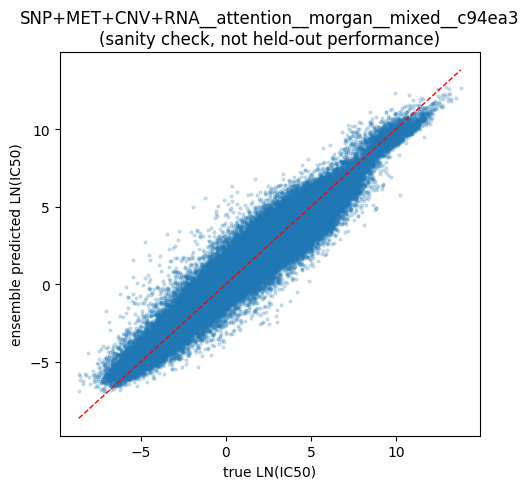

In [5]:
result = ensemble.predict(raw.gene_data, raw.drug_meta, raw.pairs, ic50=raw.ic50)
print("metrics (sanity check, NOT a held-out performance number):")
for k, v in result["metrics"].items():
    print(f"  {k}: {v:.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(result["true"], result["pred"], s=4, alpha=0.2)
lims = [min(result["true"].min(), result["pred"].min()),
        max(result["true"].max(), result["pred"].max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("true LN(IC50)")
ax.set_ylabel("ensemble predicted LN(IC50)")
ax.set_title(f"{CONDITION_TAG}\n(sanity check, not held-out performance)")
plt.tight_layout()
plt.show()
